# IPL Match Analytics
**Objective:** Analyze IPL match and ball-by-ball data to uncover team performance, batting/bowling insights, and match patterns.

**Dataset:** `matches.csv` | `deliveries.csv`  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('ggplot')
os.makedirs('outputs', exist_ok=True)

In [19]:
#Load Data
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print(matches.shape)
print(deliveries.shape)

(1095, 20)
(260920, 17)


In [20]:
matches.drop_duplicates(inplace=True)
deliveries.fillna(0, inplace=True)
matches['date'] = pd.to_datetime(matches['date'])

Most Successful Teams

In [21]:
team_wins = matches['winner'].value_counts()

team_wins

,count
winner,
Mumbai Indians,144
Chennai Super Kings,138
Kolkata Knight Riders,131
Royal Challengers Bangalore,116
Rajasthan Royals,112
Sunrisers Hyderabad,88
Kings XI Punjab,88
Delhi Daredevils,67
Delhi Capitals,48


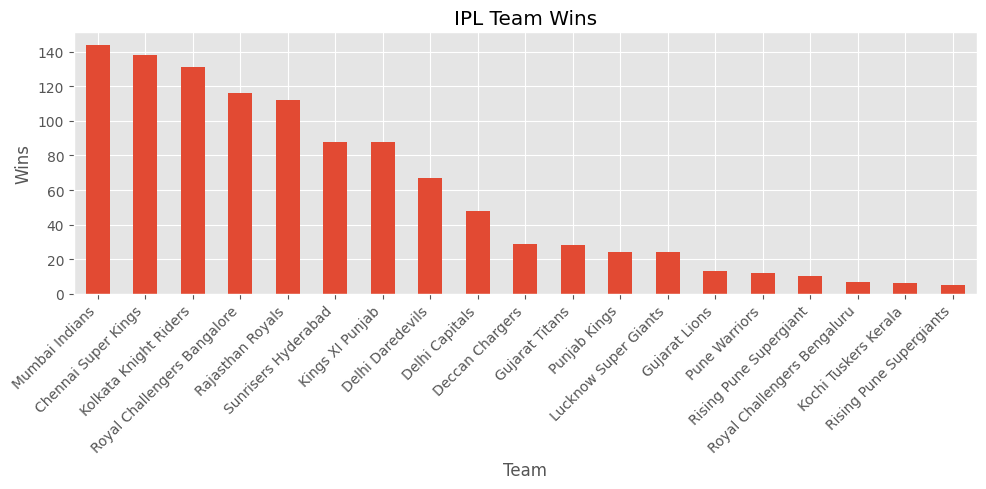

In [22]:
plt.figure(figsize=(10,5))
team_wins.plot(kind='bar')
plt.title('IPL Team Wins')
plt.xlabel('Team')
plt.ylabel('Wins')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/team_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

Toss Impact

In [23]:
toss_win_match_win = matches[matches['toss_winner'] == matches['winner']]
percentage = len(toss_win_match_win) / len(matches) * 100
print(f"Toss winner also won the match: {percentage:.2f}%")

Toss winner also won the match: 50.59%


Top Run Scorers

In [24]:
batsman_runs = deliveries.groupby('batter')['batsman_runs'].sum()
top_batsmen = batsman_runs.sort_values(ascending=False).head(10)

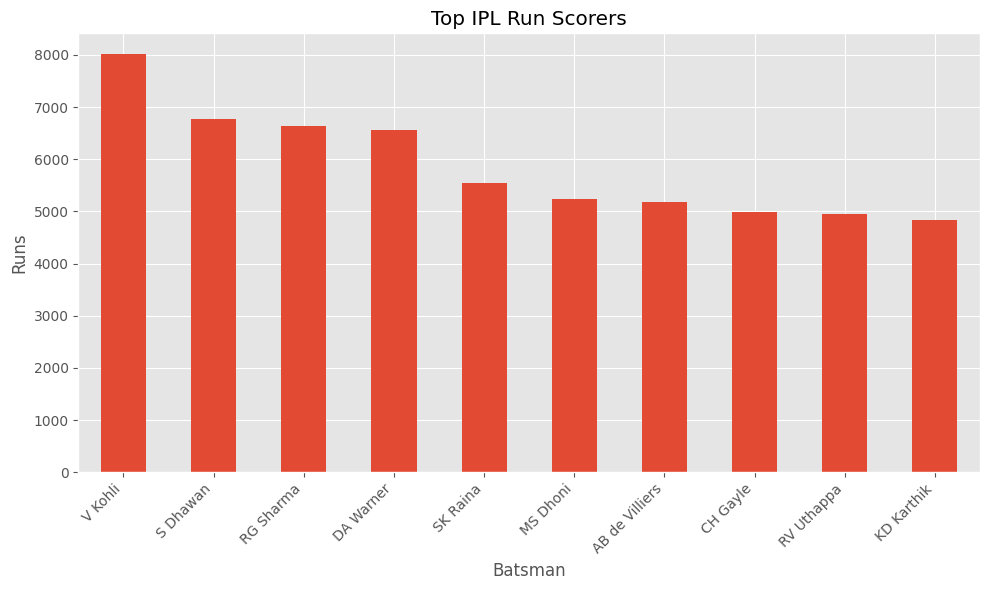

In [25]:
plt.figure(figsize=(10,6))
top_batsmen.plot(kind='bar')
plt.title('Top IPL Run Scorers')
plt.xlabel('Batsman')
plt.ylabel('Runs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/batting_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

Best Strike Rates(Minimum 1000 runs filter)

In [26]:
runs = deliveries.groupby('batter')['batsman_runs'].sum()
balls = deliveries.groupby('batter').size()
strike_rate = runs / balls * 100

stats = pd.DataFrame({'runs': runs, 'balls': balls, 'sr': strike_rate})
stats = stats[stats['runs'] > 1000]
stats.sort_values('sr', ascending=False).head(10)

,runs,balls,sr
batter,,,
AD Russell,2488,1515,164.224422
SP Narine,1534,984,155.894309
N Pooran,1769,1143,154.768154
GJ Maxwell,2772,1842,150.488599
Abhishek Sharma,1377,925,148.864865
V Sehwag,2728,1833,148.827059
AB de Villiers,5181,3487,148.580442
YBK Jaiswal,1607,1095,146.757991
SO Hetmyer,1243,854,145.550351


Best Bowlers

In [27]:
runs_given = deliveries.groupby('bowler')['total_runs'].sum()
balls_bowled = deliveries.groupby('bowler').size()
economy = runs_given / (balls_bowled / 6)

bowling_stats = pd.DataFrame({
    'runs_given': runs_given,
    'balls_bowled': balls_bowled,
    'economy': economy
})

# Minimum 600 balls (100 overs)
bowling_stats = bowling_stats[bowling_stats['balls_bowled'] >= 600]

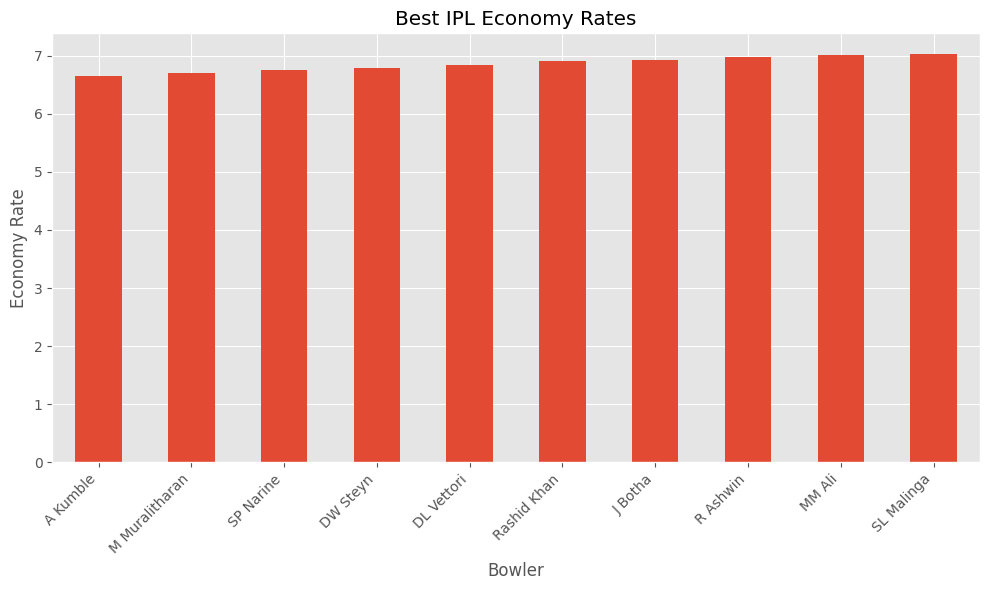

,runs_given,balls_bowled,economy
bowler,,,
A Kumble,1089,983,6.646999
M Muralitharan,1765,1581,6.698292
SP Narine,4672,4146,6.761216
DW Steyn,2583,2282,6.791411
DL Vettori,894,785,6.833121
Rashid Khan,3340,2901,6.907963
J Botha,818,709,6.922426
R Ashwin,5435,4679,6.969438
MM Ali,900,770,7.012987


In [28]:
best_economy = bowling_stats.sort_values('economy')

plt.figure(figsize=(10,6))
best_economy.head(10)['economy'].plot(kind='bar')
plt.title('Best IPL Economy Rates')
plt.ylabel('Economy Rate')
plt.xlabel('Bowler')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

best_economy.head(10)

In [29]:
wickets_df = deliveries[
    (deliveries['is_wicket'] == 1) &
    (~deliveries['dismissal_kind'].isin(['run out', 'retired hurt', 'obstructing the field']))
]

top_wicket_takers = wickets_df.groupby('bowler').size().sort_values(ascending=False)

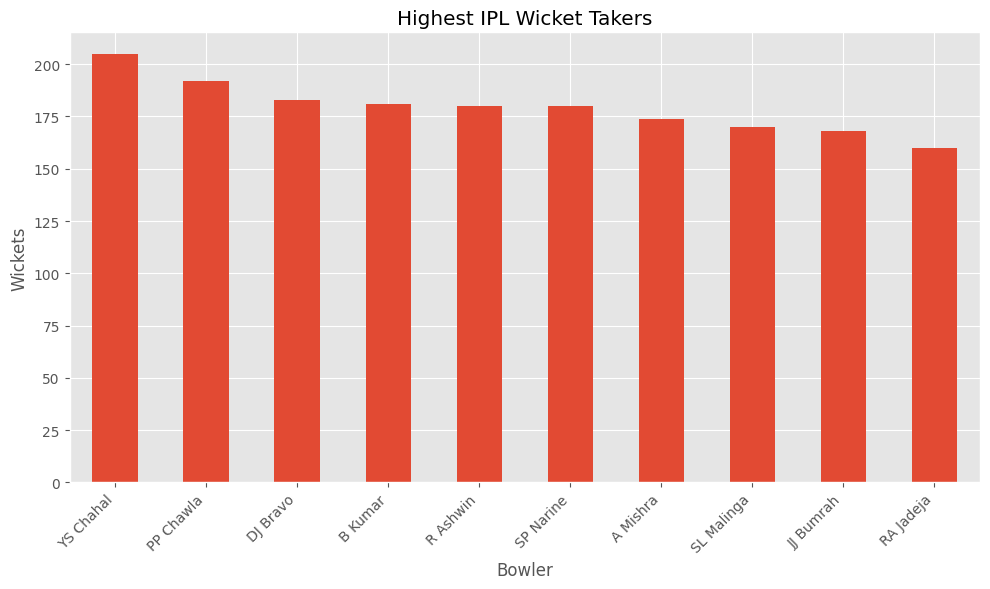

,0
bowler,
YS Chahal,205
PP Chawla,192
DJ Bravo,183
B Kumar,181
R Ashwin,180
SP Narine,180
A Mishra,174
SL Malinga,170
JJ Bumrah,168


In [30]:
plt.figure(figsize=(10,6))
top_wicket_takers.head(10).plot(kind='bar')
plt.title('Highest IPL Wicket Takers')
plt.ylabel('Wickets')
plt.xlabel('Bowler')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/bowling_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

top_wicket_takers.head(10)

Venue Analysis

In [31]:
venue_wins = matches.groupby(['venue', 'winner']).size().reset_index(name='wins')
top_venues = matches['venue'].value_counts()

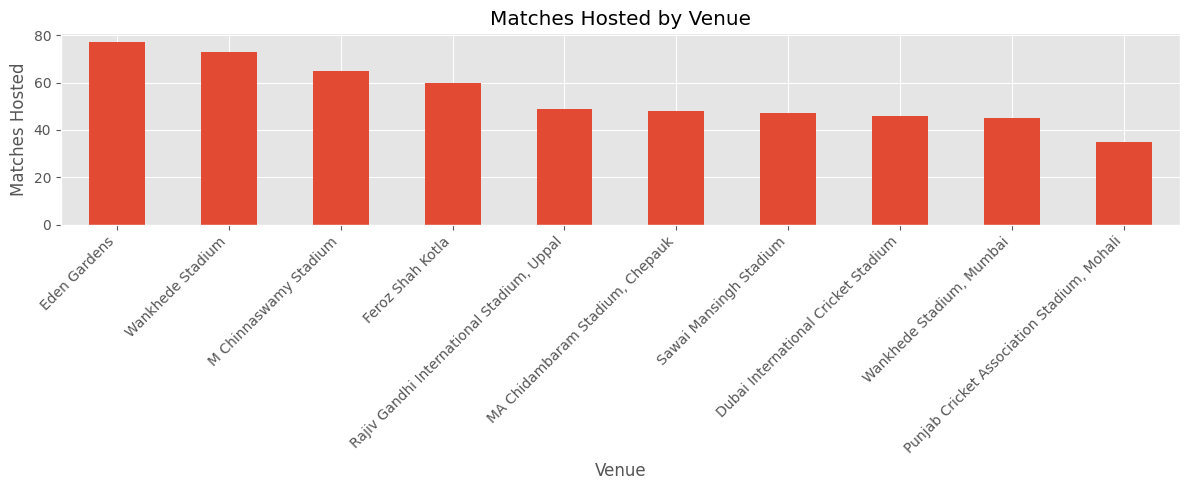

In [32]:
plt.figure(figsize=(12,5))
top_venues.head(10).plot(kind='bar')
plt.title('Matches Hosted by Venue')
plt.xlabel('Venue')
plt.ylabel('Matches Hosted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Team Win Percentage

In [33]:
played1 = matches['team1'].value_counts()
played2 = matches['team2'].value_counts()
played = played1.add(played2, fill_value=0)
wins = matches['winner'].value_counts()
win_pct = wins / played * 100

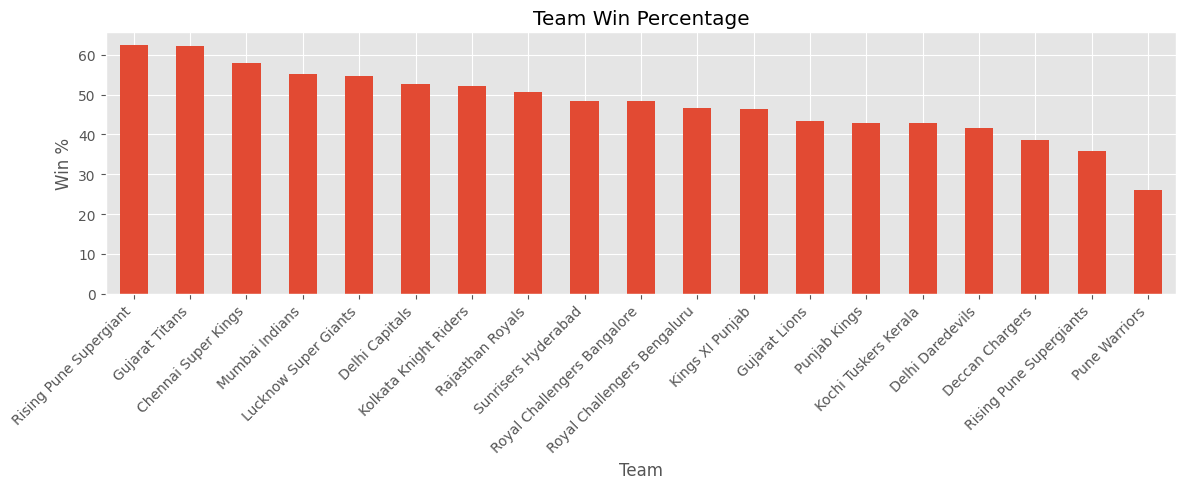

In [34]:
plt.figure(figsize=(12,5))
win_pct.sort_values(ascending=False).plot(kind='bar')
plt.title('Team Win Percentage')
plt.xlabel('Team')
plt.ylabel('Win %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Runs Distribution

In [35]:
match_runs = deliveries.groupby('match_id')['total_runs'].sum()

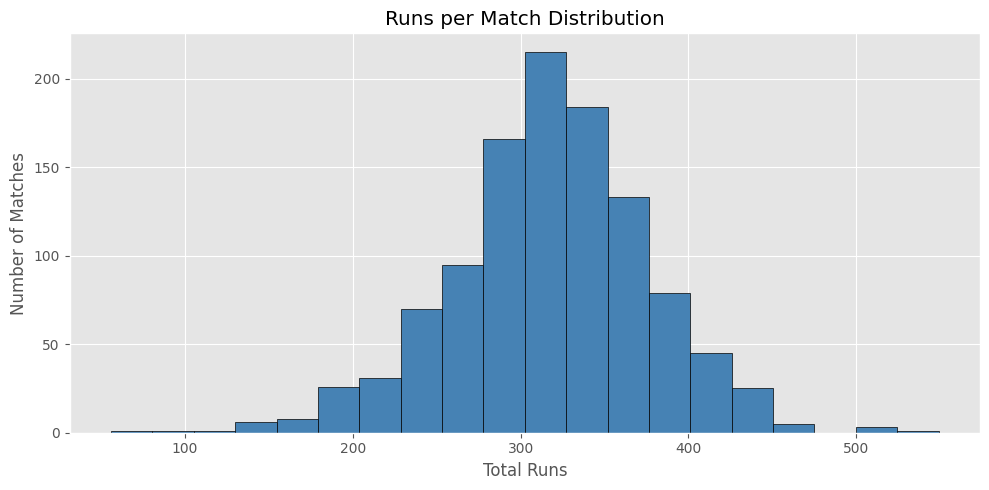

In [36]:
plt.figure(figsize=(10,5))
plt.hist(match_runs, bins=20, color='steelblue', edgecolor='black')
plt.title('Runs per Match Distribution')
plt.xlabel('Total Runs')
plt.ylabel('Number of Matches')
plt.tight_layout()
plt.show()

Powerplay vs Death Overs

In [37]:
powerplay = deliveries[deliveries['over'] <= 6]
death = deliveries[deliveries['over'] >= 16]

Powerplay avg runs/ball: 1.24
Death overs avg runs/ball: 1.62


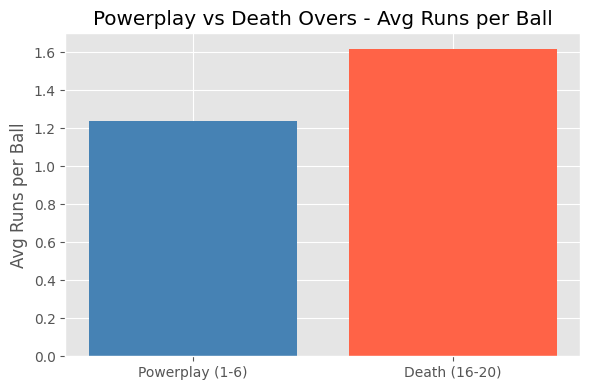

In [38]:
pp_avg = powerplay['total_runs'].mean()
death_avg = death['total_runs'].mean()

print(f"Powerplay avg runs/ball: {pp_avg:.2f}")
print(f"Death overs avg runs/ball: {death_avg:.2f}")

plt.figure(figsize=(6,4))
plt.bar(['Powerplay (1-6)', 'Death (16-20)'], [pp_avg, death_avg], color=['steelblue', 'tomato'])
plt.title('Powerplay vs Death Overs - Avg Runs per Ball')
plt.ylabel('Avg Runs per Ball')
plt.tight_layout()
plt.show()

Dashboard

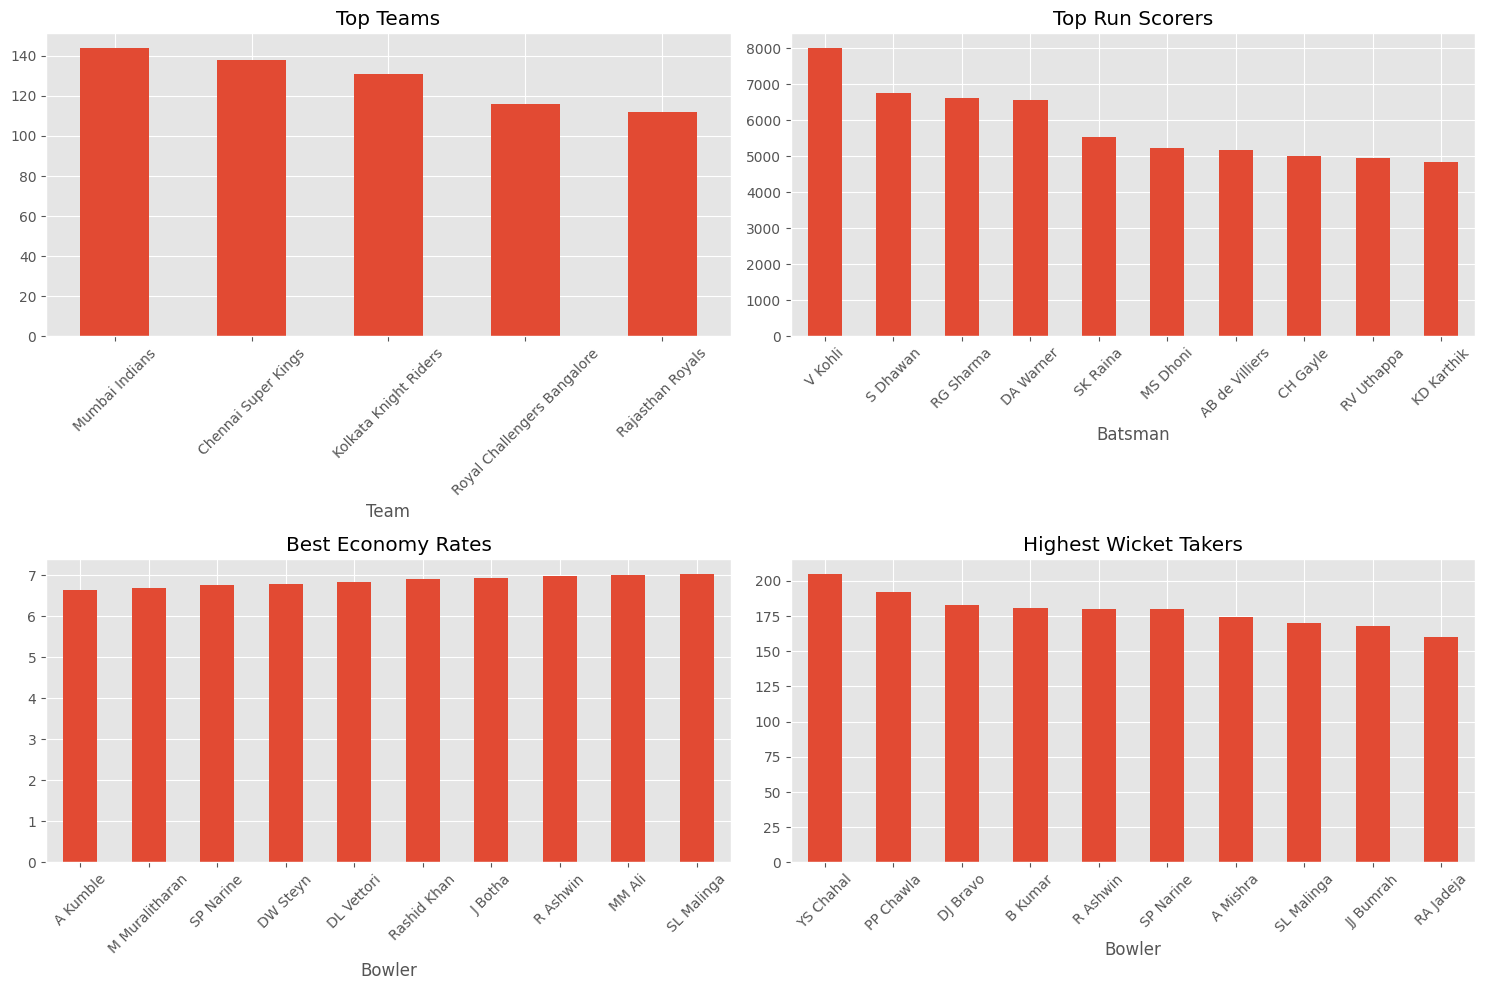

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(15,10))

team_wins.head(5).plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Top Teams')
axes[0,0].set_xlabel('Team')
axes[0,0].tick_params(axis='x', rotation=45)

top_batsmen.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Top Run Scorers')
axes[0,1].set_xlabel('Batsman')
axes[0,1].tick_params(axis='x', rotation=45)

best_economy.head(10)['economy'].plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Best Economy Rates')
axes[1,0].set_xlabel('Bowler')
axes[1,0].tick_params(axis='x', rotation=45)

top_wicket_takers.head(10).plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Highest Wicket Takers')
axes[1,1].set_xlabel('Bowler')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('outputs/ipl_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()